
Training RNN...
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 54ms/step - accuracy: 0.6489 - loss: 0.6179 - val_accuracy: 0.5986 - val_loss: 0.6446
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.7320 - loss: 0.5405 - val_accuracy: 0.7876 - val_loss: 0.5053
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.8197 - loss: 0.4030 - val_accuracy: 0.7516 - val_loss: 0.5378
RNN Accuracy: 0.7467

Training LSTM...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 154ms/step - accuracy: 0.7887 - loss: 0.4592 - val_accuracy: 0.8226 - val_loss: 0.4029
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 160ms/step - accuracy: 0.8913 - loss: 0.2769 - val_accuracy: 0.8566 - val_loss: 0.3633
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 164ms/step - accuracy: 0.9258 - loss: 0.1987 - val_accuracy: 0.8650 - val_loss: 0.3612
LSTM Accuracy: 0.8582

Training GRU...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 163ms/step - accuracy: 0.7857 - loss: 0.4495 - val_accuracy: 0.8488 - val_loss: 0.3515
Epoch 2/3
313/313 ━━━━━━━

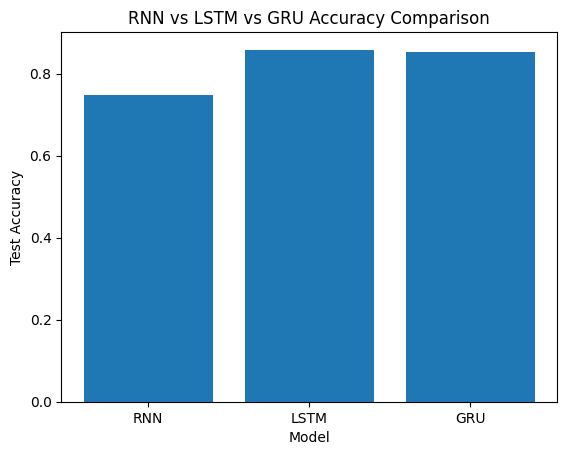

In [4]:
# ================================
# RNN vs LSTM vs GRU
# ================================

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import matplotlib.pyplot as plt

#print("TensorFlow Version:",tf._version_)

# -------------------------------
# LOAD DATA
# -------------------------------
vocab_size = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

# -------------------------------
# MODEL FUNCTION
# -------------------------------
def create_model(model_type):
    model = Sequential()
    model.add(Embedding(vocab_size, 128, input_length=max_len))

    if model_type == "RNN":
        model.add(SimpleRNN(64))
    elif model_type == "LSTM":
        model.add(LSTM(64))
    elif model_type == "GRU":
        model.add(GRU(64))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# -------------------------------
# TRAIN + STORE HISTORY
# -------------------------------
model_types = ["RNN", "LSTM", "GRU"]
results = {}
histories = {}

for m in model_types:
    print(f"\nTraining {m}...")

    model = create_model(m)

    history = model.fit(
        x_train, y_train,
        epochs=3,
        batch_size=64,
        validation_split=0.2,
        verbose=1
    )

    loss, acc = model.evaluate(x_test, y_test, verbose=0)

    results[m] = acc
    histories[m] = history

    print(f"{m} Accuracy: {acc:.4f}")

# -------------------------------
# BAR GRAPH (FINAL COMPARISON)
# -------------------------------
plt.figure()
plt.bar(results.keys(), results.values())
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("RNN vs LSTM vs GRU Accuracy Comparison")
plt.show()